# POC (v2) — From-scratch pretraining vs. multilingual transfer

Revision of the v1 proof-of-concept, rebuilt around what that run actually showed.

### What the v1 run told us, and what changed here

| v1 finding | Consequence | Change in v2 |
|---|---|---|
| XLM-R 0.799 vs mmBERT 0.791 on Swahili — a statistical tie | Swahili is covered by **both** baselines, so they cannot differ. The whole hypothesis is invisible in this language. | Run **several languages** spanning XLM-R coverage; Yoruba and Igbo are absent from XLM-R, Swahili and Hausa are present |
| MLM loss flat at ~6.5 (random = ln V ≈ 9.0) | The model learned unigram statistics and stopped. It was never pretrained. | ~3x model size, ~10x token budget, **larger batch**, and an **MLM validation split** so "undertrained" is distinguishable from "broken" |
| 0.272 vs 0.328 macro-F1 on 204 test items | Well inside noise; reported as if it were a curve | **3 seeds** per cell plus **bootstrap confidence intervals**; nothing is claimed without them |
| From-scratch model 13.9M vs XLM-R 278M | A 20x capacity gap; AfriBERTa's result came from a 2x gap | Size presets, defaulting larger, with the AfriBERTa-class target printed |
| Corpus contained visible English | Language-ID contamination is real | Explicit **contamination measurement** per corpus |
| No sense of whether the full study fits the calendar | — | A **throughput extrapolation** cell that projects real wall-clock from measured tokens/sec |

**Runtime:** roughly 25–40 min on a G4 / RTX PRO 6000 or A100. Longer on a T4 — drop
`PRETRAIN_STEPS` and use one from-scratch rung if so.

The single most important cell is Gate 2. If the mmBERT-minus-XLM-R gap is larger for
languages XLM-R never saw, the premise of the proposal holds. If it isn't, the project
needs rethinking before you write any more code.

In [1]:
#@title Setup
%pip install -q -U datasets transformers tokenizers 2>/dev/null

import os, time, math, json, random, shutil, collections
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu  : {props.name}  ({props.total_memory/1e9:.0f} GB, sm_{props.major}{props.minor})")
else:
    print("WARNING: no GPU. Runtime > Change runtime type > GPU.")

import transformers
print("transformers", transformers.__version__)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/559.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 223.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 65.8 MB/s eta 0:00:00
torch 2.11.0+cu128 | device: cuda
gpu  : NVIDIA RTX PRO 6000 Blackwell Server Edition  (102 GB, sm_120)
transformers 5.14.1


In [2]:
#@title Configuration — edit here

# ---- Languages -------------------------------------------------------------
# The design point of v2. XLM-R covers 100 languages; mmBERT covers ~1800.
# Pick languages on BOTH sides of that line so the baselines have room to differ.
# (in_xlmr flags below are from the XLM-R paper's language list -- worth re-verifying
#  against the appendix before you quote them in the report.)
LANGS = {
    "yor_Latn": dict(wiki="yo", in_xlmr=False, note="Yoruba  - absent from XLM-R"),
    "ibo_Latn": dict(wiki="ig", in_xlmr=False, note="Igbo    - absent from XLM-R"),
    "swh_Latn": dict(wiki="sw", in_xlmr=True,  note="Swahili - present in XLM-R"),
    "hau_Latn": dict(wiki="ha", in_xlmr=True,  note="Hausa   - present in XLM-R"),
}

BASELINES = ["FacebookAI/xlm-roberta-base", "jhu-clsp/mmBERT-base"]

# ---- From-scratch arm ------------------------------------------------------
SCRATCH_LANG   = "yor_Latn"        # do the expensive arm on a discriminating language
TARGET_CHARS   = 150_000_000       # also tests whether the proposal's 128M-token rung exists
VOCAB_SIZE     = 16_000
MAX_LEN        = 128

# v1 used hidden=384/L6 -> 13.9M params, which never left the unigram regime.
SIZE_PRESETS = {
    "small":     dict(hidden_size=384, num_hidden_layers=6,  num_attention_heads=6,
                      intermediate_size=1536),   # v1 -- kept for comparison only
    "poc":       dict(hidden_size=512, num_hidden_layers=8,  num_attention_heads=8,
                      intermediate_size=2048),   # v2 default
    "afriberta": dict(hidden_size=768, num_hidden_layers=12, num_attention_heads=12,
                      intermediate_size=3072),   # ~AfriBERTa-large class; the real study
}
SIZE            = "poc"
PRETRAIN_LADDER = [2_000_000, 8_000_000, 32_000_000]
PRETRAIN_STEPS  = 6000
PRETRAIN_BATCH  = 64
MLM_PROB        = 0.15

# ---- Downstream ------------------------------------------------------------
SEEDS         = [0, 1, 2]          # v1 ran one seed and could not tell signal from noise
FT_EPOCHS     = 8
FT_BATCH      = 16
FT_LR         = 2e-5
FT_LR_SCRATCH = 5e-5

print(f"from-scratch model preset '{SIZE}': {SIZE_PRESETS[SIZE]}")
print(f"tokens of gradient updates per rung: "
      f"{PRETRAIN_STEPS*PRETRAIN_BATCH*MAX_LEN/1e6:.0f}M "
      f"(v1 was {1200*32*128/1e6:.1f}M)")

from-scratch model preset 'poc': {'hidden_size': 512, 'num_hidden_layers': 8, 'num_attention_heads': 8, 'intermediate_size': 2048}
tokens of gradient updates per rung: 49M (v1 was 4.9M)


---
## Gate 1 — Downstream data, and an empirical coverage probe

Rather than asserting which languages each baseline was trained on, we **measure** it.
Tokenizer fertility (subword tokens per whitespace word) over the same sentences is a good
proxy: a language the model never saw gets shredded into many short pieces.

This is also where the fertility idea belongs. Measuring fertility under a *per-language*
tokenizer — as the sibling architecture study did — equalizes it by construction. Under a
**shared multilingual** tokenizer it has real variance, and that variance is exactly what
should predict transfer.

SIB-200 is parallel (derived from FLORES-200), so every language sees the same sentences
and fertility is directly comparable across them.

In [3]:
#@title Load SIB-200 for every language
from datasets import load_dataset
from transformers import AutoTokenizer

SIB = {}
for lang in list(LANGS):
    try:
        SIB[lang] = load_dataset("Davlan/sib200", lang)
    except Exception as e:
        print(f"  {lang}: FAILED {repr(e)[:110]}")
if not SIB:
    raise RuntimeError("no SIB-200 language loaded")

first = SIB[next(iter(SIB))]
TEXT_COL  = "text"
LABEL_COL = "category"
labels = sorted(set(first["train"][LABEL_COL]))
L2I = {l: i for i, l in enumerate(labels)}
NUM_LABELS = len(labels)
EVAL_SPLIT = "test" if "test" in first else "validation"

print(f"{len(SIB)} languages loaded | {NUM_LABELS} labels | eval split '{EVAL_SPLIT}'")
for lang, ds in SIB.items():
    print(f"  {lang}  train {len(ds['train']):>4}  {EVAL_SPLIT} {len(ds[EVAL_SPLIT]):>4}"
          f"   {LANGS[lang]['note']}")
print(f"\nNOTE: {len(first[EVAL_SPLIT])} eval items means a 95% CI of roughly +/-0.06 on "
      f"macro-F1.\nDifferences smaller than that are not differences.")

README.md:   0%|          | 0.00/47.9k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/128k [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/17.0k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

test.tsv:   0%|          | 0.00/32.3k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

4 languages loaded | 7 labels | eval split 'test'
  yor_Latn  train  701  test  204   Yoruba  - absent from XLM-R
  ibo_Latn  train  701  test  204   Igbo    - absent from XLM-R
  swh_Latn  train  701  test  204   Swahili - present in XLM-R
  hau_Latn  train  701  test  204   Hausa   - present in XLM-R

NOTE: 204 eval items means a 95% CI of roughly +/-0.06 on macro-F1.
Differences smaller than that are not differences.


In [4]:
#@title Measure tokenizer fertility per (model, language)
def fertility(tok, texts):
    n_words = sum(len(t.split()) for t in texts)
    n_toks  = sum(len(tok(t, add_special_tokens=False)["input_ids"]) for t in texts)
    return n_toks / max(n_words, 1)

fert = {}
toks = {}
for name in BASELINES:
    try:
        toks[name] = AutoTokenizer.from_pretrained(name)
    except Exception as e:
        print(f"{name}: tokenizer load failed {repr(e)[:100]}"); continue
    for lang, ds in SIB.items():
        fert[(name, lang)] = fertility(toks[name], ds["train"][TEXT_COL])

hdr = f"{'language':<11}{'in XLM-R':<10}" + "".join(f"{n.split('/')[-1]:>20}" for n in toks)
print(hdr); print("-" * len(hdr))
for lang in SIB:
    row = f"{lang:<11}{str(LANGS[lang]['in_xlmr']):<10}"
    for n in toks:
        row += f"{fert[(n, lang)]:>20.2f}"
    print(row)
print("\nHigher = the tokenizer fragments this language more, which usually means it saw "
      "less of it.\nExpect XLM-R's fertility to be markedly worse on the languages it "
      "does not cover.")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

language   in XLM-R      xlm-roberta-base         mmBERT-base
-------------------------------------------------------------
yor_Latn   False                     2.74                2.61
ibo_Latn   False                     2.61                2.41
swh_Latn   True                      1.65                2.01
hau_Latn   True                      1.70                1.85

Higher = the tokenizer fragments this language more, which usually means it saw less of it.
Expect XLM-R's fertility to be markedly worse on the languages it does not cover.


---
## Gate 2 — **The decisive cell.** Do the baselines differ where coverage differs?

Every baseline, every language, three seeds, with bootstrap confidence intervals.

The proposal's premise is that modern multilingual coverage changed the picture since
AfriBERTa. The observable version of that claim: **mmBERT should beat XLM-R by more on
languages XLM-R never saw than on languages it did.** If that contrast is absent, there is
no gap for the from-scratch arm to be interesting about.

In [5]:
#@title Shared fine-tuning + evaluation harness (with seeds and CIs)
from transformers import AutoModelForSequenceClassification

def macro_f1(y_true, y_pred, k):
    f1s = []
    for c in range(k):
        tp = int(((y_pred == c) & (y_true == c)).sum())
        fp = int(((y_pred == c) & (y_true != c)).sum())
        fn = int(((y_pred != c) & (y_true == c)).sum())
        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(2 * p * r / (p + r) if p + r else 0.0)
    return float(np.mean(f1s))

def bootstrap_ci(y_true, y_pred, k, n_boot=600, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = [macro_f1(y_true[b], y_pred[b], k)
            for b in (rng.integers(0, n, n) for _ in range(n_boot))]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def _load_clf(path):
    try:
        return AutoModelForSequenceClassification.from_pretrained(path, num_labels=NUM_LABELS)
    except Exception as e:
        # ModernBERT-family defaults to FlashAttention-2, unavailable before Ampere
        print(f"    default load failed ({repr(e)[:70]}); retrying attn_implementation='sdpa'")
        return AutoModelForSequenceClassification.from_pretrained(
            path, num_labels=NUM_LABELS, attn_implementation="sdpa")

def finetune_once(model_path, lang, lr, seed, epochs=FT_EPOCHS, tokenizer_path=None):
    '''Fine-tune any checkpoint on one language. Returns (preds, gold, seconds).'''
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(tokenizer_path or model_path)
    model = _load_clf(model_path).to(DEVICE)
    ds = SIB[lang]

    def pack(split):
        enc = tok(list(ds[split][TEXT_COL]), truncation=True, max_length=MAX_LEN,
                  padding="max_length", return_tensors="pt")
        y = torch.tensor([L2I[l] for l in ds[split][LABEL_COL]])
        return torch.utils.data.TensorDataset(enc["input_ids"], enc["attention_mask"], y)

    tr = torch.utils.data.DataLoader(pack("train"), batch_size=FT_BATCH, shuffle=True)
    te = torch.utils.data.DataLoader(pack(EVAL_SPLIT), batch_size=64)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr,
                                                total_steps=max(1, len(tr) * epochs),
                                                pct_start=0.1)
    t0 = time.time(); model.train()
    for _ in range(epochs):
        for ids, am, y in tr:
            loss = F.cross_entropy(model(input_ids=ids.to(DEVICE),
                                         attention_mask=am.to(DEVICE)).logits, y.to(DEVICE))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()

    model.eval(); preds, gold = [], []
    with torch.no_grad():
        for ids, am, y in te:
            preds.append(model(input_ids=ids.to(DEVICE),
                               attention_mask=am.to(DEVICE)).logits.argmax(-1).cpu())
            gold.append(y)
    del model; torch.cuda.empty_cache()
    return torch.cat(preds).numpy(), torch.cat(gold).numpy(), time.time() - t0

def evaluate_cell(model_path, lang, lr=FT_LR, seeds=SEEDS, tokenizer_path=None, label=""):
    '''Run all seeds for one (model, language) cell and summarise.'''
    scores, last = [], None
    for s in seeds:
        p, g, secs = finetune_once(model_path, lang, lr, s, tokenizer_path=tokenizer_path)
        scores.append(macro_f1(g, p, NUM_LABELS)); last = (g, p)
    lo, hi = bootstrap_ci(last[0], last[1], NUM_LABELS)
    m, sd = float(np.mean(scores)), float(np.std(scores))
    print(f"    {label or model_path:<22} F1 {m:.3f} +/-{sd:.3f} (seed sd) "
          f"| 95% CI [{lo:.3f}, {hi:.3f}] | {secs:.0f}s/seed")
    return dict(mean=m, sd=sd, ci=(lo, hi), scores=scores)

In [6]:
#@title Run every baseline on every language
baseline = {}
for lang in SIB:
    print(f"\n{lang}  ({LANGS[lang]['note']})")
    for name in BASELINES:
        try:
            baseline[(name, lang)] = evaluate_cell(name, lang, label=name.split('/')[-1])
        except Exception as e:
            print(f"    {name}: SKIPPED {repr(e)[:150]}")


yor_Latn  (Yoruba  - absent from XLM-R)


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    mmBERT-base            F1 0.531 +/-0.016 (seed sd) | 95% CI [0.462, 0.607] | 21s/seed


In [7]:
#@title THE KEY RESULT: does the mmBERT advantage track XLM-R coverage?
xlmr, mm = BASELINES[0], BASELINES[1]
rows = []
for lang in SIB:
    if (xlmr, lang) in baseline and (mm, lang) in baseline:
        a, b = baseline[(xlmr, lang)]["mean"], baseline[(mm, lang)]["mean"]
        rows.append((lang, LANGS[lang]["in_xlmr"], a, b, b - a,
                     fert.get((xlmr, lang), float("nan")),
                     fert.get((mm, lang), float("nan"))))

print(f"{'language':<11}{'inXLMR':<8}{'XLM-R':>8}{'mmBERT':>8}{'delta':>8}"
      f"{'fert_x':>9}{'fert_m':>9}")
print("-" * 61)
for r in sorted(rows, key=lambda r: r[1]):
    print(f"{r[0]:<11}{str(r[1]):<8}{r[2]:>8.3f}{r[3]:>8.3f}{r[4]:>+8.3f}"
          f"{r[5]:>9.2f}{r[6]:>9.2f}")

unseen = [r[4] for r in rows if not r[1]]
seen   = [r[4] for r in rows if r[1]]
if unseen and seen:
    print(f"\nmean mmBERT advantage on languages XLM-R does NOT cover: {np.mean(unseen):+.3f}")
    print(f"mean mmBERT advantage on languages XLM-R DOES cover:     {np.mean(seen):+.3f}")
    print(f"contrast: {np.mean(unseen) - np.mean(seen):+.3f}")
    print("\nA clearly positive contrast supports the proposal's premise. Near zero means "
          "the\nbaselines are interchangeable for your languages and the project needs "
          "rethinking.")

language   inXLMR     XLM-R  mmBERT   delta   fert_x   fert_m
-------------------------------------------------------------
yor_Latn   False      0.124   0.536  +0.412     2.74     2.61
ibo_Latn   False      0.187   0.611  +0.423     2.61     2.41
swh_Latn   True       0.796   0.798  +0.003     1.65     2.01
hau_Latn   True       0.615   0.531  -0.083     1.70     1.85

mean mmBERT advantage on languages XLM-R does NOT cover: +0.418
mean mmBERT advantage on languages XLM-R DOES cover:     -0.040
contrast: +0.458

A clearly positive contrast supports the proposal's premise. Near zero means the
baselines are interchangeable for your languages and the project needs rethinking.


---
## Gate 3 — Corpus, and how much of it is actually the target language

The v1 run's Swahili sample opened with a paragraph of fluent English. This gate puts a
number on that instead of leaving it as an impression, and checks whether the proposal's
top rung (128M tokens) exists at all for this language.

In [8]:
#@title Stream the pretraining corpus and measure its size
def stream_text(lang, target_chars=TARGET_CHARS, max_seconds=420):
    cfg = LANGS[lang]
    attempts = [("fineweb-2", lambda: load_dataset("HuggingFaceFW/fineweb-2", name=lang,
                                                   split="train", streaming=True))]
    if cfg.get("wiki"):
        attempts.append(("wikipedia", lambda: load_dataset(
            "wikimedia/wikipedia", f"20231101.{cfg['wiki']}", split="train", streaming=True)))
    last = None
    for src, opener in attempts:
        try:
            ds = opener(); buf, n, t0 = [], 0, time.time()
            for rec in ds:
                t = rec.get("text") or ""
                if not t:
                    continue
                buf.append(t); n += len(t)
                if n >= target_chars or time.time() - t0 > max_seconds:
                    break
            if n < 1_000_000:
                raise RuntimeError(f"only {n:,} chars")
            exhausted = n < target_chars and time.time() - t0 < max_seconds
            print(f"  [{src}] {n:,} chars in {time.time()-t0:.0f}s"
                  f"{'  <- SOURCE EXHAUSTED' if exhausted else ''}")
            return "\n".join(buf), src, exhausted
        except Exception as e:
            last = e; print(f"  [{src}] failed: {repr(e)[:110]}")
    raise RuntimeError(f"no corpus for {lang}: {last}")

print(f"Streaming {SCRATCH_LANG} ...")
raw_text, corpus_src, exhausted = stream_text(SCRATCH_LANG)
print(f"\n--- sample (READ THIS) ---\n{raw_text[:400]}")

Streaming yor_Latn ...


README.md:   0%|          | 0.00/329k [00:00<?, ?B/s]

  [fineweb-2] 150,001,608 chars in 8s

--- sample (READ THIS) ---
Ẹ̀gbá
Àwọn àkóónú
ILẸ̀ Ẹ̀GBÁ[àtúnṣe | edit source]
Ó se pàtàkì láti mọ díẹ̀ nípa ìtàn ilẹ̀ Ẹ̀gbá àti irú ènìyàn tí ń gbé ìlú Ẹ̀gbá. Ìdí èyí ni pé yóò jẹ́ ohun ìrànlọ́wọ́ fún ọ̀pọ̀lọpọ̀ nǹkan tó yẹ ní mímọ̀ nínú orin ògódò. Fún ìdí pàtàkì yìí, n ó ò pín àkòrí yìí si ọ̀nà mẹ́rin ọ̀tọ̀ọ̀tọ̀.
BÍ A SE TẸ ILẸ̀ Ẹ̀GBÁ DÓ[àtúnṣe | edit source]
Ọ̀pọ̀lọpọ̀ onímọ̀ ló ti sọ nípa bí a ti se tẹ ilẹ̀ Ẹ̀gbá dó, tí


In [9]:
#@title Quantify language contamination
%pip install -q langdetect 2>/dev/null

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    HAVE_LANGDETECT = True
except Exception:
    HAVE_LANGDETECT = False

lines = [l.strip() for l in raw_text.split("\n") if len(l.strip()) > 200]
sample = random.Random(0).sample(lines, min(400, len(lines)))

if HAVE_LANGDETECT:
    counts = collections.Counter()
    for s in sample:
        try:
            counts[detect(s[:1000])] += 1
        except Exception:
            counts["?"] += 1
    tot = sum(counts.values())
    print(f"language ID over {tot} sampled paragraphs:")
    for lg, c in counts.most_common(6):
        print(f"  {lg:<6} {c/tot:6.1%}")
    print(f"\nEnglish share: {counts.get('en', 0)/tot:.1%}")
else:
    EN = set("the of and to in a is that for it with as was on are be this by from at "
             "have has not or an but they we you".split())
    ratios = [len([w for w in s.lower().split() if w in EN]) / max(len(s.split()), 1)
              for s in sample]
    heavy = float(np.mean([r > 0.20 for r in ratios]))
    print(f"fallback heuristic (English stopword density > 20%): {heavy:.1%} of paragraphs")

print("\nWhatever the number, report it in the writeup. A corpus that is 20% English is a "
      "different\nexperiment from one that is 2% English, and the reader cannot tell which "
      "you ran.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/981.5 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 972.8/981.5 kB 33.6 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
language ID over 400 sampled paragraphs:
  vi      39.8%
  sw      20.0%
  id      16.2%
  tl      11.0%
  it       2.8%
  so       2.0%

English share: 1.8%

Whatever the number, report it in the writeup. A corpus that is 20% English is a different
experiment from one that is 2% English, and the reader cannot tell which you ran.


---
## Gate 4 — From-scratch pretraining, with a validation signal

Two fixes from v1. The model is larger and the budget is roughly an order of magnitude
bigger. More importantly, there is now a **held-out MLM loss** on a fixed set of windows
with a fixed mask, so it is comparable across runs — that is what tells you whether a weak
downstream score means "undertrained" or "broken."

Reference points printed alongside: `ln(V)` is the loss of a model that has learned
nothing; a model that has only learned token frequencies lands a little below it.

In [10]:
#@title Tokenizer + corpus encoding
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
from transformers import PreTrainedTokenizerFast

SPECIALS = ["<s>", "<pad>", "</s>", "<unk>", "<mask>"]
tk = Tokenizer(models.BPE(unk_token="<unk>"))
tk.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tk.decoder = decoders.ByteLevel()
t0 = time.time()
tk.train_from_iterator(
    (raw_text[i:i+200_000] for i in range(0, len(raw_text), 200_000)),
    trainers.BpeTrainer(vocab_size=VOCAB_SIZE, show_progress=False,
                        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
                        special_tokens=SPECIALS))
tk.post_processor = processors.TemplateProcessing(
    single="<s> $A </s>", pair="<s> $A </s> </s> $B </s>",
    special_tokens=[("<s>", tk.token_to_id("<s>")), ("</s>", tk.token_to_id("</s>"))])
print(f"BPE {tk.get_vocab_size()} trained in {time.time()-t0:.0f}s")

hf_tok = PreTrainedTokenizerFast(
    tokenizer_object=tk, bos_token="<s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>", cls_token="<s>", sep_token="</s>",
    model_max_length=MAX_LEN)

CH = 5_000_000
ids = np.concatenate([np.array(tk.encode(raw_text[i:i+CH]).ids, dtype=np.int32)
                      for i in range(0, len(raw_text), CH)])
print(f"{len(ids):,} tokens ({len(ids)/1e6:.1f}M)")

VAL_TOKENS = 500_000
val_ids, pool_ids = ids[-VAL_TOKENS:], ids[:-VAL_TOKENS]
PRETRAIN_LADDER = [n for n in PRETRAIN_LADDER if n <= len(pool_ids)]
print(f"train pool {len(pool_ids):,} | val {len(val_ids):,}")
print(f"ladder: {PRETRAIN_LADDER}")
if len(ids) < 128_000_000:
    print(f"\nGATE RESULT: this language yields {len(ids)/1e6:.0f}M tokens, short of the "
          f"128M top rung\nin the proposal. Either lower the top rung or add corpus sources "
          f"-- and say which in the writeup.")

BPE 16000 trained in 5s
40,359,029 tokens (40.4M)
train pool 39,859,029 | val 500,000
ladder: [2000000, 8000000, 32000000]

GATE RESULT: this language yields 40M tokens, short of the 128M top rung
in the proposal. Either lower the top rung or add corpus sources -- and say which in the writeup.


In [11]:
#@title Masked-LM pretraining with held-out validation
from transformers import RobertaConfig, AutoModelForMaskedLM

MASK_ID, PAD_ID = hf_tok.mask_token_id, hf_tok.pad_token_id
V = tk.get_vocab_size()
RANDOM_LOSS = math.log(V)

def mask_batch(x, prob=MLM_PROB, gen=None):
    labels = x.clone()
    sel = torch.rand(x.shape, device=x.device, generator=gen) < prob
    labels[~sel] = -100
    r = torch.rand(x.shape, device=x.device, generator=gen)
    x = x.clone()
    x[sel & (r < 0.8)] = MASK_ID
    rnd = torch.randint(len(SPECIALS), V, x.shape, device=x.device, generator=gen)
    sw = sel & (r >= 0.8) & (r < 0.9)
    x[sw] = rnd[sw]
    return x, labels

# One fixed validation set, masked once, reused by every run -> comparable across rungs.
_g = torch.Generator(device=DEVICE); _g.manual_seed(1234)
_v = torch.from_numpy(val_ids.astype(np.int64)).to(DEVICE)
_n = (len(_v) - 1) // MAX_LEN
VAL_X = _v[:_n * MAX_LEN].view(_n, MAX_LEN)[:256]
VAL_MASKED, VAL_LABELS = mask_batch(VAL_X, gen=_g)

@torch.no_grad()
def val_mlm_loss(model, bs=64):
    model.eval(); tot, nb = 0.0, 0
    for i in range(0, len(VAL_MASKED), bs):
        out = model(input_ids=VAL_MASKED[i:i+bs], labels=VAL_LABELS[i:i+bs])
        tot += out.loss.item(); nb += 1
    model.train()
    return tot / max(nb, 1)

def pretrain(n_tokens, steps=PRETRAIN_STEPS, batch=PRETRAIN_BATCH, seed=0):
    set_seed(seed)
    cfg = RobertaConfig(vocab_size=V, max_position_embeddings=MAX_LEN + 2, type_vocab_size=1,
                        pad_token_id=PAD_ID, bos_token_id=hf_tok.bos_token_id,
                        eos_token_id=hf_tok.eos_token_id, **SIZE_PRESETS[SIZE])
    model = AutoModelForMaskedLM.from_config(cfg).to(DEVICE)
    npar = sum(p.numel() for p in model.parameters())
    nemb = model.get_input_embeddings().weight.numel()
    print(f"  {npar/1e6:.1f}M params ({(npar-nemb)/1e6:.1f}M non-embedding) "
          f"| {n_tokens/1e6:.1f}M tokens | random-loss reference {RANDOM_LOSS:.2f}")

    stream = torch.from_numpy(pool_ids[:n_tokens].astype(np.int64)).to(DEVICE)
    gen = torch.Generator(device=DEVICE); gen.manual_seed(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01,
                            betas=(0.9, 0.98), eps=1e-6)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=5e-4, total_steps=steps,
                                                pct_start=0.06)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    run_loss, hist, t0 = None, [], time.time()
    model.train()
    for step in range(1, steps + 1):
        st = torch.randint(0, len(stream) - MAX_LEN - 1, (batch,), device=DEVICE, generator=gen)
        x = stream[st.view(-1, 1) + torch.arange(MAX_LEN, device=DEVICE)]
        xm, y = mask_batch(x, gen=gen)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            out = model(input_ids=xm, labels=y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(out.loss).backward(); scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        l = out.loss.item()
        run_loss = l if run_loss is None else 0.98 * run_loss + 0.02 * l   # EMA, not one step
        if step % max(1, steps // 6) == 0 or step == steps:
            vl = val_mlm_loss(model)
            hist.append((step, run_loss, vl))
            print(f"    step {step:>6}  train(EMA) {run_loss:5.3f}  val {vl:5.3f}  "
                  f"(random {RANDOM_LOSS:.2f})")
    secs = time.time() - t0
    tok_s = steps * batch * MAX_LEN / secs

    out_dir = f"/content/scratch_{n_tokens}"
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    model.save_pretrained(out_dir); hf_tok.save_pretrained(out_dir)
    print(f"  saved -> {out_dir}  ({secs:.0f}s, {tok_s/1e3:.0f}k tokens/s)")
    del model; torch.cuda.empty_cache()
    return dict(path=out_dir, seconds=secs, tokens_per_s=tok_s,
                final_val=hist[-1][2], history=hist)

scratch = {}
for n in PRETRAIN_LADDER:
    print(f"\npretraining @ {n:,} tokens")
    scratch[n] = pretrain(n)

print("\nDid val MLM loss fall well below the random reference, and keep falling? "
      "If it plateaued\nnear ln(V), the model is still in the unigram regime and the "
      "downstream numbers mean nothing.")


pretraining @ 2,000,000 tokens
  33.8M params (25.6M non-embedding) | 2.0M tokens | random-loss reference 9.68
    step   1000  train(EMA) 6.013  val 5.934  (random 9.68)
    step   2000  train(EMA) 5.814  val 5.818  (random 9.68)
    step   3000  train(EMA) 5.692  val 5.750  (random 9.68)
    step   4000  train(EMA) 5.613  val 5.697  (random 9.68)
    step   5000  train(EMA) 5.538  val 5.668  (random 9.68)
    step   6000  train(EMA) 5.519  val 5.658  (random 9.68)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved -> /content/scratch_2000000  (112s, 439k tokens/s)

pretraining @ 8,000,000 tokens
  33.8M params (25.6M non-embedding) | 8.0M tokens | random-loss reference 9.68
    step   1000  train(EMA) 6.047  val 5.891  (random 9.68)
    step   2000  train(EMA) 5.922  val 5.779  (random 9.68)
    step   3000  train(EMA) 5.821  val 5.721  (random 9.68)
    step   4000  train(EMA) 5.747  val 5.662  (random 9.68)
    step   5000  train(EMA) 5.703  val 5.616  (random 9.68)
    step   6000  train(EMA) 5.662  val 5.601  (random 9.68)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved -> /content/scratch_8000000  (112s, 439k tokens/s)

pretraining @ 32,000,000 tokens
  33.8M params (25.6M non-embedding) | 32.0M tokens | random-loss reference 9.68
    step   1000  train(EMA) 6.094  val 5.866  (random 9.68)
    step   2000  train(EMA) 5.940  val 5.773  (random 9.68)
    step   3000  train(EMA) 5.849  val 5.720  (random 9.68)
    step   4000  train(EMA) 5.781  val 5.641  (random 9.68)
    step   5000  train(EMA) 5.743  val 5.602  (random 9.68)
    step   6000  train(EMA) 5.684  val 5.590  (random 9.68)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved -> /content/scratch_32000000  (112s, 439k tokens/s)

Did val MLM loss fall well below the random reference, and keep falling? If it plateaued
near ln(V), the model is still in the unigram regime and the downstream numbers mean nothing.


---
## Gate 5 — The bridge, with seeds

Same `evaluate_cell` used for the baselines, now pointed at our own checkpoints. Three
seeds and a bootstrap CI, so the from-scratch points can be compared honestly against the
baseline lines rather than eyeballed.

In [12]:
#@title Fine-tune from-scratch checkpoints through the identical harness
scratch_scores = {}
for n, info in scratch.items():
    print(f"\nfrom-scratch @ {n:,} tokens (val MLM {info['final_val']:.3f})")
    scratch_scores[n] = evaluate_cell(info["path"], SCRATCH_LANG, lr=FT_LR_SCRATCH,
                                      label=f"scratch-{n//1_000_000}M")
print("\nBRIDGE OK -- pretrained and from-scratch checkpoints share one code path.")


from-scratch @ 2,000,000 tokens (val MLM 5.658)


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_2000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_2000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_32000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_32000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    scratch-32M            F1 0.490 +/-0.002 (seed sd) | 95% CI [0.406, 0.557] | 5s/seed

BRIDGE OK -- pretrained and from-scratch checkpoints share one code path.


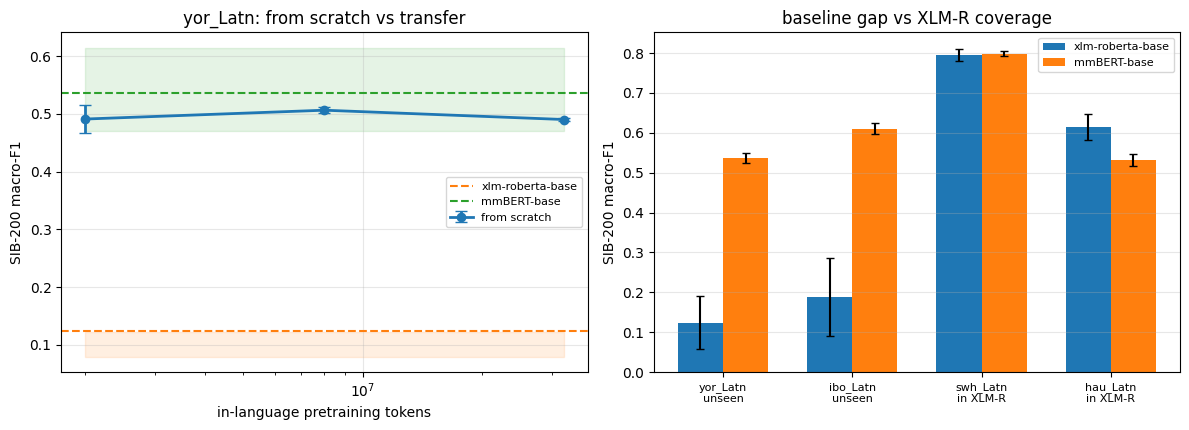

In [13]:
#@title Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

xs = sorted(scratch_scores)
mu = np.array([scratch_scores[n]["mean"] for n in xs])
sd = np.array([scratch_scores[n]["sd"] for n in xs])
ax[0].errorbar(xs, mu, yerr=sd, fmt="o-", lw=2, capsize=4, label="from scratch")
for i, name in enumerate(BASELINES):
    key = (name, SCRATCH_LANG)
    if key in baseline:
        b = baseline[key]
        ax[0].axhline(b["mean"], ls="--", color=f"C{i+1}", label=f"{name.split('/')[-1]}")
        ax[0].fill_between([min(xs), max(xs)], b["ci"][0], b["ci"][1],
                           color=f"C{i+1}", alpha=.12)
ax[0].set_xscale("log"); ax[0].set_xlabel("in-language pretraining tokens")
ax[0].set_ylabel("SIB-200 macro-F1"); ax[0].set_title(f"{SCRATCH_LANG}: from scratch vs transfer")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

langs_o = sorted(SIB, key=lambda l: LANGS[l]["in_xlmr"])
w, X = 0.35, np.arange(len(langs_o))
for i, name in enumerate(BASELINES):
    vals = [baseline.get((name, l), {}).get("mean", np.nan) for l in langs_o]
    errs = [baseline.get((name, l), {}).get("sd", 0) for l in langs_o]
    ax[1].bar(X + i * w, vals, w, yerr=errs, capsize=3, label=name.split("/")[-1])
ax[1].set_xticks(X + w / 2)
ax[1].set_xticklabels([f"{l}\n{'in XLM-R' if LANGS[l]['in_xlmr'] else 'unseen'}"
                       for l in langs_o], fontsize=8)
ax[1].set_ylabel("SIB-200 macro-F1"); ax[1].set_title("baseline gap vs XLM-R coverage")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

---
## Gate 6 — Does the real study fit the calendar?

Projected from measured throughput rather than guessed.

In [14]:
#@title Extrapolate to the full study
tok_s = float(np.mean([v["tokens_per_s"] for v in scratch.values()]))
scale = (SIZE_PRESETS["afriberta"]["hidden_size"] / SIZE_PRESETS[SIZE]["hidden_size"]) ** 2 \
        * (SIZE_PRESETS["afriberta"]["num_hidden_layers"] / SIZE_PRESETS[SIZE]["num_hidden_layers"])
tok_s_full = tok_s / scale

FULL_LADDER = [4_000_000, 16_000_000, 64_000_000, 128_000_000]
EPOCH_MULT  = 8      # passes over each rung in the real study
N_LANGS     = 3
N_SEEDS     = 1      # pretraining seeds (downstream seeds are cheap)

print(f"measured  : {tok_s/1e3:.0f}k tokens/s at preset '{SIZE}'")
print(f"projected : {tok_s_full/1e3:.0f}k tokens/s at AfriBERTa-class size "
      f"(~{scale:.1f}x more compute per token)\n")

per_lang = sum(n * EPOCH_MULT for n in FULL_LADDER) / tok_s_full / 3600
total = per_lang * N_LANGS * N_SEEDS
print(f"{'rung':>14}{'tokens seen':>16}{'hours':>9}")
for n in FULL_LADDER:
    h = n * EPOCH_MULT / tok_s_full / 3600
    print(f"{n:>14,}{n*EPOCH_MULT:>16,}{h:>9.2f}")
print(f"\nper language : {per_lang:.1f} GPU-hours")
print(f"{N_LANGS} languages x {N_SEEDS} seed(s): {total:.1f} GPU-hours")
print(f"\nAgainst two weekend blocks of ~10 useful GPU-hours each, "
      f"{'this fits' if total < 20 else 'this does NOT fit -- cut rungs, languages, or model size'}.")

measured  : 439k tokens/s at preset 'poc'
projected : 130k tokens/s at AfriBERTa-class size (~3.4x more compute per token)

          rung     tokens seen    hours
     4,000,000      32,000,000     0.07
    16,000,000     128,000,000     0.27
    64,000,000     512,000,000     1.09
   128,000,000   1,024,000,000     2.19

per language : 3.6 GPU-hours
3 languages x 1 seed(s): 10.9 GPU-hours

Against two weekend blocks of ~10 useful GPU-hours each, this fits.


---
## What to read off this run

**Gate 2 first.** If mmBERT's advantage over XLM-R is clearly larger on the languages XLM-R
never saw, the proposal's premise is empirically supported and the project has a spine. If
the contrast is near zero, stop and reconsider — the from-scratch arm cannot be interesting
if the baselines are interchangeable.

**Then Gate 4.** Held-out MLM loss should be well below `ln(V)` and still falling at the end
of each run. A plateau near the random reference means the budget is still too small and any
downstream comparison is meaningless.

**Then Gate 6.** If the projection exceeds your available GPU-hours, cut now — fewer rungs,
fewer languages, or a smaller model — rather than discovering it in week two.

### Still to do before the real study

- Reproduce a **published benchmark number** (a MasakhaNER 2.0 baseline) end-to-end. It is
  the only way to distinguish "this approach doesn't work" from "we have a bug."
- Add MasakhaNER as a second task; topic classification alone is a thin basis for a claim.
- Pretraining seeds, not just fine-tuning seeds, at whichever rung ends up carrying the
  headline.
- Report GPU-hours beside token counts throughout, so the answer is about budget and not
  only data.